In [1]:
!pip install tensorflow-cpu==2.16.2
!pip install matplotlib

In [3]:
import tensorflow as tf

2026-06-11 12:12:39.976410: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-11 12:12:40.022187: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
import numpy as np
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train/127.5 - 1
x_train = np.expand_dims(x_train, axis=-1)
x_train.shape

(60000, 28, 28, 1)

In [17]:
from tensorflow.keras.layers import Dense, Input, Reshape, Flatten, Conv2D, LeakyReLU, BatchNormalization, Conv2D, Conv2DTranspose
from tensorflow.keras.models import Sequential

# Hyperparameters
NOISE_DIM = 100  
IMG_SHAPE = (28, 28, 1)
BUFFER_SIZE = 60000
BATCH_SIZE = 256

def build_generator():
    model = Sequential([
        # 1. Take the 100 noise numbers and project to a small 7x7 image map
        Input(shape=(NOISE_DIM,)),
        Dense(7 * 7 * 256, use_bias=False),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.2),
        Reshape((7, 7, 256)),

        # 2. Upsample to 14x14
        Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.2),

        # 3. Upsample to 28x28 (Final MNIST size)
        Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    
    return model

    
def build_discriminator():
    model = Sequential([
        Input(shape=IMG_SHAPE),
        Flatten(),
        Dense(512, activation='leaky_relu'),
        Dense(256, activation='leaky_relu'),
        Dense(1, activation='sigmoid')
    ])

    return model


In [18]:
generator = build_generator()
discriminator = build_discriminator()

In [19]:
loss_fn = tf.keras.losses.BinaryCrossentropy()
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)

In [20]:
def train_step(images):
    noise = tf.random.normal((BATCH_SIZE, NOISE_DIM))

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, Training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = loss_fn(tf.ones_like(fake_output),fake_output)

        disc_real_loss = loss_fn(tf.ones_like(real_output), real_output)
        disc_fake_loss = loss_fn(tf.zeros_like(fake_output), fake_output)

        disc_loss = disc_real_loss + disc_fake_loss

    generator_gradient = gen_tape.gradient(gen_loss, generator.trainable_weights)
    discriminator_gradient = disc_tape.gradient(disc_loss, discriminator.trainable_weights)

    generator_optimizer.apply_gradients(zip(generator_gradient, generator.trainable_weights))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradient, discriminator.trainable_weights))

    


In [ ]:

train_datset = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)

for epoch in range(15):
    print(f"Epoch {epoch+1}")
    for x_train_batch in train_datset:
        train_step(x_train_batch)
        
    # Optional: Print out a test sample generation at the end of every epoch
        if (epoch + 1) % 5 == 0 or epoch == 0:
            test_noise = tf.random.normal([1, NOISE_DIM])
            sample = generator(test_noise, training=False)
            print(f"Epoch {epoch+1} complete. Generator outputs are evolving.")

Epoch 1
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are evolving.
Epoch 1 complete. Generator outputs are ev

2026-06-11 13:53:36.103677: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


D LOSS: 0.5039 | D ACC: 0.7266 | G LOSS: 0.8202
D LOSS: 0.8373 | D ACC: 0.6364 | G LOSS: 1.7384
D LOSS: 0.4922 | D ACC: 0.7999 | G LOSS: 4.1591
D LOSS: 0.3586 | D ACC: 0.8544 | G LOSS: 5.6783
D LOSS: 0.2729 | D ACC: 0.8898 | G LOSS: 6.3329
D LOSS: 0.2206 | D ACC: 0.9112 | G LOSS: 6.4343
D LOSS: 0.1850 | D ACC: 0.9258 | G LOSS: 6.5641
D LOSS: 0.1589 | D ACC: 0.9363 | G LOSS: 6.7904
D LOSS: 0.1396 | D ACC: 0.9441 | G LOSS: 6.9714
D LOSS: 0.1242 | D ACC: 0.9502 | G LOSS: 7.2043
D LOSS: 0.1119 | D ACC: 0.9552 | G LOSS: 7.3429
D LOSS: 0.1019 | D ACC: 0.9592 | G LOSS: 7.4489
D LOSS: 0.0934 | D ACC: 0.9626 | G LOSS: 7.5502
D LOSS: 0.0863 | D ACC: 0.9655 | G LOSS: 7.6376
D LOSS: 0.0804 | D ACC: 0.9679 | G LOSS: 7.7157
D LOSS: 0.0751 | D ACC: 0.9700 | G LOSS: 7.7369
D LOSS: 0.0704 | D ACC: 0.9719 | G LOSS: 7.8273
D LOSS: 0.0663 | D ACC: 0.9735 | G LOSS: 7.8837
D LOSS: 0.0627 | D ACC: 0.9750 | G LOSS: 7.9370
D LOSS: 0.0595 | D ACC: 0.9763 | G LOSS: 7.9637
D LOSS: 0.0566 | D ACC: 0.9775 | G LOSS:

Final Output Tensor Shape: (25, 28, 28, 1)


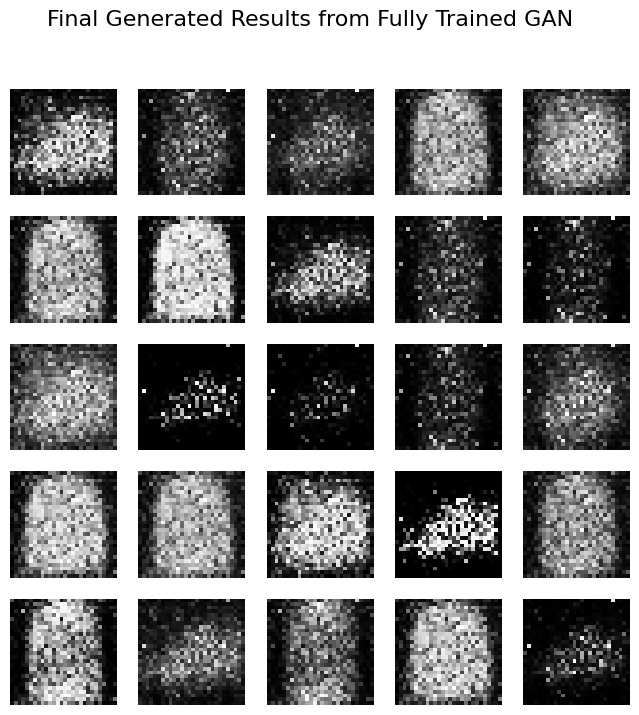

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Generate a final batch of 25 completely new digits
num_samples = 25
final_noise = tf.random.normal([num_samples, NOISE_DIM])

# Set training=False so Dropout/BatchNorm layers behave correctly
final_generated_images = generator(final_noise, training=False)

print("Final Output Tensor Shape:", final_generated_images.shape) 
# Should output: (25, 28, 28, 1)

# 2. Set up a clean 5x5 grid for comparison
plt.figure(figsize=(8, 8))
for i in range(num_samples):
    plt.subplot(5, 5, i + 1)
    
    # Denormalize: Convert [-1, 1] back to [0, 255] for visual clarity
    img = (final_generated_images[i, :, :, 0].numpy() * 127.5 + 127.5)
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.suptitle("Final Generated Results from Fully Trained GAN", fontsize=16)
plt.show()